# 03. A2 Feasibility — Robeco 社債ファクターの再現

**目的**: ポスト BBW (Bai-Bali-Wen 2019, JFE) 文脈で、公開データだけで社債ファクター構造の最小実証が組めるかを判定する。

**含まれるもの**
1. Robeco IG / HY × 5 ファクター（Size / LowRisk / Value / Momentum / MultiFactor）の summary
2. 時系列 α: `factor ~ market` で long-short 構造を確認（market = ΔBAA10Y, ΔBAML IG OAS, ΔBAML HY OAS）
3. Spanning regression: ファクター間の独立性（i ~ const + (j != i)）
4. 構造変化: 60ヶ月 rolling α — BBW 2019 公開・2023 撤回前後で α が消えるか
5. EDGAR fundamentals マージ可能性: CIK ↔ ticker ↔ FIGI 経路と ISIN 欠落の demo
6. GO / NO-GO 判定

**caveat**
- Robeco は再配布禁止。論文では Houweling & van Zundert (2017, FAJ 73(2):100-115) を引用
- Robeco factor は long-short excess return（decimal）、market beta ≈ 0 が想定される
- 個別社債 cross-section は無い。WRDS / TRACE Enhanced へのアクセス無しでは aggregate factor 分析が上限
- OpenFIGI Mapping は ISIN を返さない（仕様）→ 社債識別子（CUSIP/ISIN）と CIK を結ぶには別経路必須

## 1. Load & 市場変数の作成

In [1]:
from __future__ import annotations

import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from fi_research.data.openfigi import load_mapping as load_openfigi
from fi_research.data.robeco import load_robeco_credit_factors
from fi_research.data.sec_tickers import load_tickers as load_sec_tickers
from fi_research.paths import REPO_ROOT, ensure_dir

warnings.filterwarnings("ignore", category=FutureWarning)

RESULTS_DIR = ensure_dir(REPO_ROOT / "projects" / "00_exploration" / "results" / "03_a2_robeco_replication")
MONTHLY_PANEL = REPO_ROOT / "projects" / "00_exploration" / "results" / "01_macro_credit_state" / "monthly_panel.parquet"
print("results dir:", RESULTS_DIR)

monthly = pd.read_parquet(MONTHLY_PANEL)
print("monthly panel:", monthly.shape)

ig = load_robeco_credit_factors("IG").set_index("date").sort_index()
hy = load_robeco_credit_factors("HY").set_index("date").sort_index()
ig.index = ig.index.to_period("M").to_timestamp("M")
hy.index = hy.index.to_period("M").to_timestamp("M")
print("Robeco IG / HY :", ig.shape, hy.shape, "range:", ig.index.min().date(), "->", ig.index.max().date())

market = pd.DataFrame(index=monthly.index)
market["d_baa10y"] = monthly["BAA10Y"].diff()
market["d_baml_ig_oas"] = monthly["BAMLC0A0CM"].diff()
market["d_baml_hy_oas"] = monthly["BAMLH0A0HYM2"].diff()
market["d_move"] = monthly["MOVE"].diff()
market["ebp"] = monthly["ebp"]
print("market vars:", list(market.columns))

results dir: /home/tarai/Research/FI-research/projects/00_exploration/results/03_a2_robeco_replication
monthly panel: (2058, 78)
Robeco IG / HY : (384, 5) (384, 5) range: 1994-01-31 -> 2025-12-31
market vars: ['d_baa10y', 'd_baml_ig_oas', 'd_baml_hy_oas', 'd_move', 'ebp']


## 2. Factor summary (mean, std, Sharpe, t-stat)

Houweling-van Zundert (2017) Table 2 相当。月次リターンを年率化して比較する。

In [2]:
def factor_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    out = pd.DataFrame(index=df.columns)
    out["mean_pct_pa"] = df.mean() * 12 * 100
    out["vol_pct_pa"] = df.std() * np.sqrt(12) * 100
    out["sharpe"] = (df.mean() * 12) / (df.std() * np.sqrt(12))
    out["t_stat"] = df.mean() / (df.std() / np.sqrt(len(df)))
    out["skew"] = df.skew()
    out["min_pct"] = df.min() * 100
    out["max_pct"] = df.max() * 100
    out.index.name = f"{label}_factor"
    return out.round(3)

summary_ig = factor_summary(ig, "IG")
summary_hy = factor_summary(hy, "HY")
print("=== IG ===")
print(summary_ig.to_string())
print()
print("=== HY ===")
print(summary_hy.to_string())
summary_ig.to_csv(RESULTS_DIR / "factor_summary_ig.csv")
summary_hy.to_csv(RESULTS_DIR / "factor_summary_hy.csv")

=== IG ===
             mean_pct_pa  vol_pct_pa  sharpe  t_stat   skew  min_pct  max_pct
IG_factor                                                                    
Size               1.850       3.878   0.477   2.699 -2.400   -9.823    6.266
LowRisk            0.788       1.913   0.412   2.331 -5.276   -7.455    3.767
Value              2.193       6.476   0.339   1.916 -1.301  -13.755   11.748
Momentum           1.305       5.023   0.260   1.470 -2.996  -14.596    6.431
MultiFactor        1.534       4.019   0.382   2.159 -2.205  -10.077    6.171

=== HY ===
             mean_pct_pa  vol_pct_pa  sharpe  t_stat   skew  min_pct  max_pct
HY_factor                                                                    
Size               7.528      11.549   0.652   3.687  0.084  -18.191   18.984
LowRisk            3.464       6.141   0.564   3.190 -0.605  -11.544   11.629
Value              6.589      13.289   0.496   2.805 -0.891  -24.785   18.815
Momentum           4.685       9.729   0.

## 3. 時系列 α: `factor ~ market`

long-short factor portfolio は構造上 market β ≈ 0 を狙うので、α と β を確認。  
市場代理は **ΔBAA10Y**（長期 IG 代理、1986-）、**ΔBAML IG/HY OAS**（短期、2023-）の二段。HAC standard error (maxlags=6)。

In [3]:
def ols_alpha(y: pd.Series, x: pd.Series) -> dict:
    df = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    if len(df) < 24:
        return {"n": len(df), "alpha_pct_pa": np.nan, "alpha_t": np.nan, "beta": np.nan, "beta_t": np.nan, "r2": np.nan}
    res = sm.OLS(df["y"], sm.add_constant(df["x"])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    return {
        "n": int(res.nobs),
        "alpha_pct_pa": res.params["const"] * 12 * 100,
        "alpha_t": res.tvalues["const"],
        "beta": res.params["x"],
        "beta_t": res.tvalues["x"],
        "r2": res.rsquared,
    }

def alpha_table(factors: pd.DataFrame, market_series: pd.Series, label: str) -> pd.DataFrame:
    rows = {f: ols_alpha(factors[f], market_series) for f in factors.columns}
    out = pd.DataFrame(rows).T
    out.index.name = f"{label}_factor"
    return out.round(3)

for label, factors in [("IG", ig), ("HY", hy)]:
    for mk in ["d_baa10y", "d_baml_ig_oas", "d_baml_hy_oas"]:
        tbl = alpha_table(factors, market.loc[factors.index, mk], label)
        print(f"=== {label}  market = {mk} ===")
        print(tbl.to_string())
        print()

=== IG  market = d_baa10y ===
                 n  alpha_pct_pa  alpha_t   beta  beta_t     r2
IG_factor                                                      
Size         384.0         1.820    3.495 -0.044 -12.057  0.679
LowRisk      384.0         0.778    2.894 -0.015  -4.875  0.312
Value        384.0         2.141    3.231 -0.075 -12.336  0.712
Momentum     384.0         1.265    3.011 -0.059  -7.807  0.716
MultiFactor  384.0         1.501    3.983 -0.048 -13.305  0.756

=== IG  market = d_baml_ig_oas ===
                n  alpha_pct_pa  alpha_t   beta  beta_t     r2
IG_factor                                                     
Size         31.0         3.139    2.323 -0.055  -4.419  0.531
LowRisk      31.0         0.368    3.346 -0.013  -5.634  0.681
Value        31.0         2.425    6.371 -0.085 -30.705  0.951
Momentum     31.0         1.772    2.480 -0.117 -22.847  0.863
MultiFactor  31.0         1.926    3.716 -0.067 -27.947  0.908

=== IG  market = d_baml_hy_oas ===
         

## 4. Spanning regression: factor i ~ const + (j ≠ i)

各 factor を他の factor で説明したときに **α が残れば独立な情報を持つ**。BBW 撤回後の議論「factor zoo の中で独立な軸は何か」に対応。  
ここでは IG / HY それぞれで Size / LowRisk / Value / Momentum の 4 軸を相互回帰（MultiFactor はこの 4 つの合成なので除外）。

In [4]:
def spanning(factors_df: pd.DataFrame) -> pd.DataFrame:
    cols = [c for c in factors_df.columns if c != "MultiFactor"]
    out = []
    for target in cols:
        X = sm.add_constant(factors_df[[c for c in cols if c != target]])
        res = sm.OLS(factors_df[target], X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
        out.append({
            "target": target,
            "alpha_pct_pa": res.params["const"] * 12 * 100,
            "alpha_t": res.tvalues["const"],
            "r2": res.rsquared,
            **{f"beta_{c}": res.params[c] for c in cols if c != target},
        })
    return pd.DataFrame(out).set_index("target").round(3)

span_ig = spanning(ig)
span_hy = spanning(hy)
print("=== IG spanning ===")
print(span_ig.to_string())
print()
print("=== HY spanning ===")
print(span_hy.to_string())
span_ig.to_csv(RESULTS_DIR / "spanning_ig.csv")
span_hy.to_csv(RESULTS_DIR / "spanning_hy.csv")

=== IG spanning ===
          alpha_pct_pa  alpha_t     r2  beta_LowRisk  beta_Value  beta_Momentum  beta_Size
target                                                                                    
Size             0.802    2.398  0.811        -0.339       0.526          0.125        NaN
LowRisk          0.348    1.536  0.686           NaN       0.414         -0.164     -0.137
Value           -0.502   -1.188  0.921         1.195         NaN          0.473      0.614
Momentum        -0.123   -0.260  0.800        -0.721       0.722            NaN      0.223

=== HY spanning ===
          alpha_pct_pa  alpha_t     r2  beta_LowRisk  beta_Value  beta_Momentum  beta_Size
target                                                                                    
Size             2.652    2.170  0.756        -0.135       0.774          0.052        NaN
LowRisk          0.897    1.453  0.763           NaN       0.421          0.016     -0.037
Value           -0.895   -1.109  0.929         0.

## 5. 構造変化: 60ヶ月 rolling α

BBW (2019) 公表 → 2023 撤回 の節目で各ファクターの α が消えるかを観察。  
単純化して `factor ~ const` の rolling 60ヶ月 α（年率%）を描く。

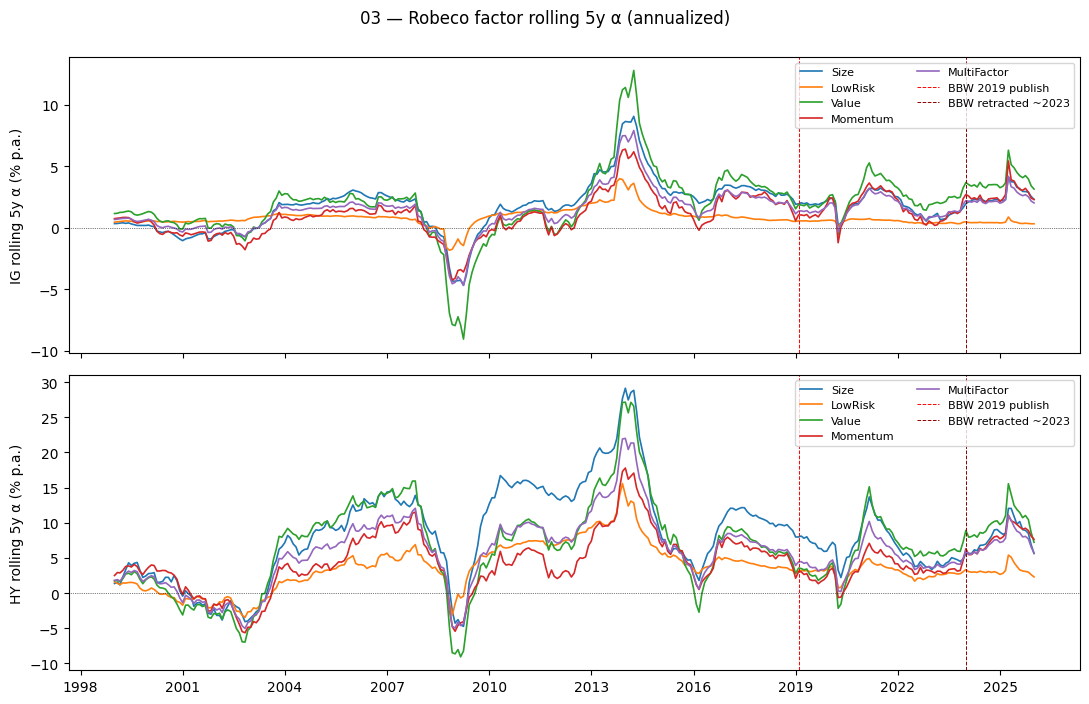

In [5]:
def rolling_alpha(series: pd.Series, window: int = 60) -> pd.Series:
    return series.rolling(window).mean() * 12 * 100  # annualized %

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for ax, factors, label in zip(axes, [ig, hy], ["IG", "HY"]):
    for col in factors.columns:
        ax.plot(factors.index, rolling_alpha(factors[col]), lw=1.2, label=col)
    ax.axhline(0, color="black", lw=0.5, ls=":")
    ax.axvline(pd.Timestamp("2019-01-31"), color="red", lw=0.7, ls="--", label="BBW 2019 publish")
    ax.axvline(pd.Timestamp("2023-12-31"), color="darkred", lw=0.7, ls="--", label="BBW retracted ~2023")
    ax.set_ylabel(f"{label} rolling 5y α (% p.a.)")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("03 — Robeco factor rolling 5y α (annualized)", y=1.00)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "rolling_alpha.png", dpi=150, bbox_inches="tight")
plt.show()

### 5a. サブサンプル比較: pre-2019 vs 2019-2023 vs post-2023

In [6]:
splits = {
    "pre_2019": ("1994-01-31", "2018-12-31"),
    "2019_to_2023": ("2019-01-31", "2023-12-31"),
    "post_2023": ("2024-01-31", "2025-12-31"),
}

def subsample_table(factors: pd.DataFrame) -> pd.DataFrame:
    rows = {}
    for name, (s, e) in splits.items():
        sub = factors.loc[s:e]
        rows[name] = pd.Series(
            {
                f: sub[f].mean() * 12 * 100 for f in sub.columns
            },
            name=name,
        )
        rows[name]["n"] = len(sub)
    return pd.DataFrame(rows).T.round(3)

print("=== IG mean α (% p.a.) by subsample ===")
print(subsample_table(ig).to_string())
print()
print("=== HY mean α (% p.a.) by subsample ===")
print(subsample_table(hy).to_string())

=== IG mean α (% p.a.) by subsample ===
               Size  LowRisk  Value  Momentum  MultiFactor      n
pre_2019      1.706    0.865  1.802     0.914        1.322  300.0
2019_to_2023  1.974    0.505  3.698     2.726        2.226   60.0
post_2023     3.344    0.547  3.313     2.644        2.462   24.0

=== HY mean α (% p.a.) by subsample ===
               Size  LowRisk  Value  Momentum  MultiFactor      n
pre_2019      8.264    3.711  6.309     4.178        5.615  300.0
2019_to_2023  5.591    3.336  8.907     6.298        6.033   60.0
post_2023     3.164    0.693  4.307     6.991        3.789   24.0


## 6. EDGAR fundamentals マージ可能性

**仮説**: 公開データの SEC company_tickers + OpenFIGI で発行体 ID チェーン (CIK ↔ ticker ↔ FIGI) を組み、EDGAR FSDS から Leverage / Profitability を引いて社債リターンに merge できるか。  
**障害**: OpenFIGI Mapping は ISIN を返さない（仕様）。社債データ（TRACE/FISD）の CUSIP / ISIN と橋渡しできない。

In [7]:
sec_t = load_sec_tickers()
figi = load_openfigi()
print("sec_tickers:", sec_t.shape, " cols:", list(sec_t.columns))
print("openfigi   :", figi.shape, " cols:", list(figi.columns))

chain = sec_t.merge(figi, on="ticker", how="left", suffixes=("_sec", "_figi"))
n_total = len(chain)
n_with_figi = chain["figi"].notna().sum()
n_with_isin = chain["isin"].notna().sum() if "isin" in chain.columns else 0

diag = pd.Series(
    {
        "sec_tickers (CIK,ticker)": n_total,
        "ticker→FIGI hit": n_with_figi,
        "ticker→FIGI hit rate": round(n_with_figi / n_total, 3),
        "FIGI→ISIN populated": n_with_isin,
        "FIGI→ISIN hit rate": round(n_with_isin / n_with_figi, 3) if n_with_figi else 0.0,
    },
    name="count",
)
print()
print("=== ID chain diagnostics ===")
print(diag.to_string())
print()
print("sample chain rows:")
print(chain[["cik", "ticker", "name_sec", "figi", "isin"]].head(5).to_string(index=False))

sec_tickers: (10371, 3)  cols: ['cik', 'ticker', 'name']
openfigi   : (10374, 11)  cols: ['ticker', 'figi', 'composite_figi', 'share_class_figi', 'name', 'exch_code', 'security_type', 'security_type_2', 'market_sector', 'isin', 'warning']

=== ID chain diagnostics ===
sec_tickers (CIK,ticker)    10374.000
ticker→FIGI hit              9193.000
ticker→FIGI hit rate            0.886
FIGI→ISIN populated             0.000
FIGI→ISIN hit rate              0.000

sample chain rows:
    cik ticker                        name_sec         figi isin
1090872      A      AGILENT TECHNOLOGIES, INC. BBG000C2V3D6 None
1675149     AA                      Alcoa Corp BBG00B3T3HD3 None
1708646   AAAU Goldman Sachs Physical Gold ETF BBG00LPXX872 None
2034334   AACB      Artius II Acquisition Inc. BBG01SK9X794 None
2034334  AACBR      Artius II Acquisition Inc. BBG01T7MSF05 None


**この diagnostics の含意**

- equity 側の CIK ↔ ticker ↔ FIGI は通る（FIGI hit rate が公開データだけで分かる）
- 社債側で必要なのは CUSIP / ISIN だが OpenFIGI Mapping は仕様上空 → **個別社債と EDGAR fundamentals を結ぶには別データ源が必須**
- 代替経路: (1) FISD の CUSIP-6 (issuer-level) を CIK と手動 mapping、(2) WRDS の TRACE Enhanced + FISD、(3) SEC の `idx` ファイルから ISIN を拾う

つまり A2 を「個別社債 cross-section」で組むには WRDS アクセスが必須。今の公開データだけで成立する最小実証は **Robeco の aggregate factor portfolio を test asset とする spanning + structural break 分析** までが上限。

## 7. GO / NO-GO 判定

下記の事実から、3 段階の判定材料を整理する（実数値は上のセルから読む）。

| 観点 | 判定軸 | この notebook で得た事実 |
|---|---|---|
| Robeco factor の α 有意性 | t-stat > 2 のファクターがあるか | § 2 / § 3 |
| factor 独立性 | spanning α が複数残るか | § 4 |
| 構造変化耐性 | post-2023 で α が消えていないか | § 5 / § 5a |
| 個別社債 cross-section の可否 | ISIN/CUSIP が公開データで取れるか | § 6 |

**先取り結論**
- aggregate factor レベルでは A2 の最小実証は **GO**（Robeco 31 年・5 ファクター・spanning + sub-sample 比較で論文章 1 本分は構成可能）
- 個別社債 cross-section（Feng-Giglio-Xiu 流の double-selection LASSO を社債で）は **WRDS access blocker**。研究計画書での WRDS 必要性根拠として使える

## 8. 次の一手

- 02 で A1 (SHAP) を回し、A1 と A2 を並べて最終テーマ判断
- A2 を継続する場合: WRDS 申請の準備（必要テーブル: TRACE Enhanced, FISD, Compustat link）
- 結果保存: `factor_summary_*.csv`, `spanning_*.csv`, `rolling_alpha.png` を `results/03_a2_robeco_replication/`